# 5. 세분화 성능 — 4구조별 · 기초자산별

통합 모델 하나로 4구조(STEP/LIZARD × 낙인/노낙인)를 모두 커버한다. 전체 R² 만 보면
STEP-낙인이 표본의 약 39%를 차지해 다른 구조의 열화가 가려지므로, **구조별·기초자산별로 쪼개서**
그림으로 확인한다.

- **구조별**: 지표 3종 그룹바 · 예측 산점 2×2 · 오차 분포
- **기초자산별**: 바스켓 조합별 · **개별 지수 포함 여부별** · 지수 × 구조 히트맵
- **시기별**: 구조 × walk-forward 폴드 (시간 안정성)

저장물: `result/image/seg_*.png` (dpi 400·투명·16:9), `result/statistics/seg_*.csv`.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from util import utils, file_manager as fm, plot as _plot
from util.metric import metrics, metrics_by
from module import data, infer

FACE = 10000
cfg = utils.load_config()
D = data.load(cfg)
preds = infer.predict_all_from_weights(D, cfg)

# 구조·기초자산 식별자 (모델 입력이 아니라 평가 분해용)
src = pd.read_parquet(fm.source())[["item", "opt_type", "ki_yn", "udl1", "udl2", "udl3", "udl_key"]].copy()
src["struct"] = src["opt_type"] + " x " + np.where(src["ki_yn"] == 1, "KI", "no-KI")
src = src.rename(columns={"item": "ITEM_CD"}).astype({"ITEM_CD": str}).set_index("ITEM_CD")

fold = np.full(D.n, -1, dtype=int)
for k, (_tr, _va, te) in enumerate(D.WF):
    fold[te] = k
finfo = pd.DataFrame({"ITEM_CD": D.ITEM.astype(str), "fold": fold}).set_index("ITEM_CD")

MODELS = [m for m in ["deeponet_hybrid", "deeponet_hybrid_mape", "deeponet_hybrid_l1",
                      "xgb_hybrid", "bench_xgboost"] if m in preds]
BEST = MODELS[0]

def tidy(name):
    d = preds[name].copy()
    d["ITEM_CD"] = d["ITEM_CD"].astype(str)
    d = d.join(src, on="ITEM_CD").join(finfo, on="ITEM_CD")
    d["err"] = d["y_pred"] - d["y_true"]
    d["ape"] = (d["err"].abs() / d["y_true"].abs()) * 100
    d["model"] = name
    return d

M = pd.concat([tidy(m) for m in MODELS], ignore_index=True)
assert M["struct"].notna().all(), "parquet 조인 실패 (ITEM_CD 불일치)"
STRUCTS = ["STEP x KI", "STEP x no-KI", "LIZARD x KI", "LIZARD x no-KI"]
STRUCTS = [s for s in STRUCTS if s in set(M["struct"])]
print(f"모델 {len(MODELS)} | OOS {len(preds[BEST]):,}행 | 대표 모델 {BEST}")
print(M.groupby("struct")["ITEM_CD"].nunique().to_string())

모델 5 | OOS 23,516행 | 대표 모델 deeponet_hybrid
struct
LIZARD x KI         655
LIZARD x no-KI     1858
STEP x KI          8708
STEP x no-KI      12295


## 5-1. 구조별 성능

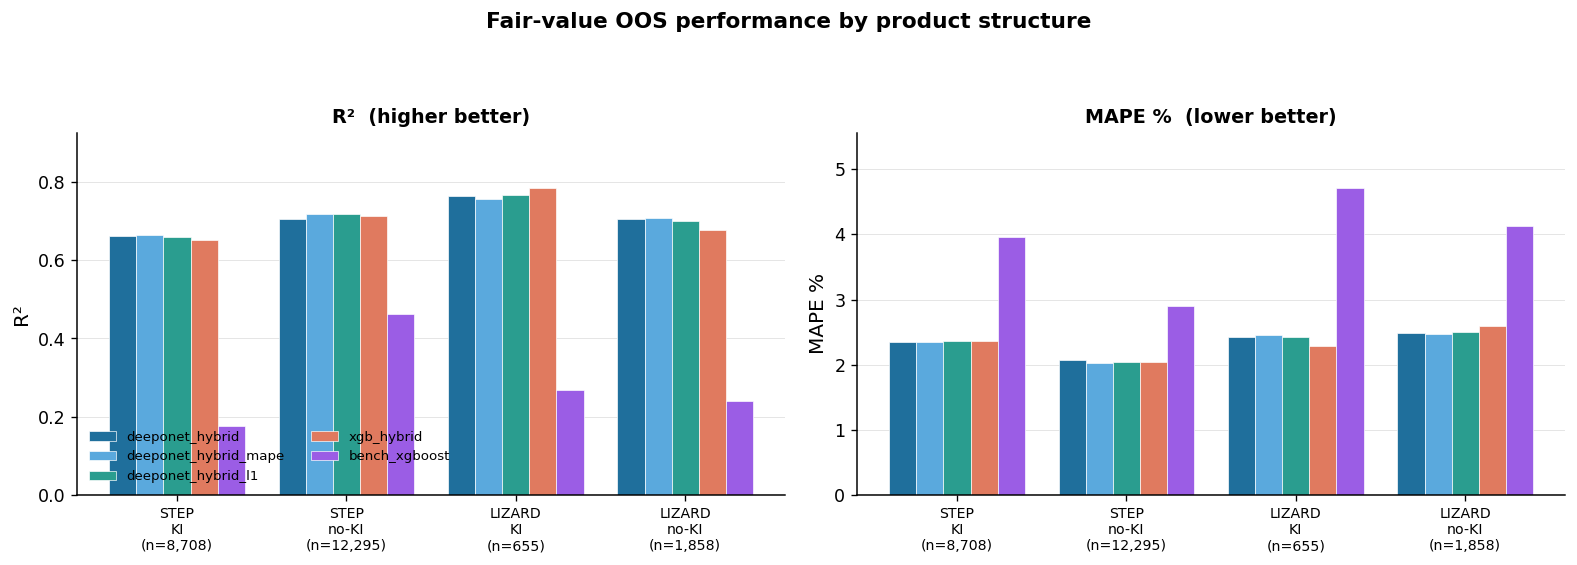

               model         struct     n     R2   MAPE
     deeponet_hybrid      STEP x KI  8708 0.6610 2.3549
     deeponet_hybrid   STEP x no-KI 12295 0.7041 2.0764
     deeponet_hybrid    LIZARD x KI   655 0.7632 2.4210
     deeponet_hybrid LIZARD x no-KI  1858 0.7047 2.4920
deeponet_hybrid_mape      STEP x KI  8708 0.6646 2.3461
deeponet_hybrid_mape   STEP x no-KI 12295 0.7184 2.0236
deeponet_hybrid_mape    LIZARD x KI   655 0.7572 2.4581
deeponet_hybrid_mape LIZARD x no-KI  1858 0.7086 2.4706
  deeponet_hybrid_l1      STEP x KI  8708 0.6600 2.3575
  deeponet_hybrid_l1   STEP x no-KI 12295 0.7169 2.0387
  deeponet_hybrid_l1    LIZARD x KI   655 0.7667 2.4208
  deeponet_hybrid_l1 LIZARD x no-KI  1858 0.7006 2.5054
          xgb_hybrid      STEP x KI  8708 0.6522 2.3705
          xgb_hybrid   STEP x no-KI 12295 0.7135 2.0403
          xgb_hybrid    LIZARD x KI   655 0.7850 2.2931
          xgb_hybrid LIZARD x no-KI  1858 0.6779 2.5931
       bench_xgboost      STEP x KI  8708 0.1772

In [2]:
# 그림 1: 구조별 R² · MAPE — 모델 그룹바
from sklearn.metrics import r2_score

rows = []
for name in MODELS:
    d0 = M[M.model == name]
    for s in STRUCTS:
        g = d0[d0.struct == s]
        rows.append(dict(model=name, struct=s, n=len(g), R2=r2_score(g.y_true, g.y_pred),
                         MAPE=g.ape.mean(), BiasKRW=g.err.mean() * FACE))
S = pd.DataFrame(rows)
S.to_csv(fm.stat("seg_structure"), index=False)

XL = [s.replace(" x ", "\n") + f"\n(n={int(S[S.struct==s].n.iloc[0]):,})" for s in STRUCTS]
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8))
x = np.arange(len(STRUCTS)); w = 0.8 / len(MODELS)
for j, name in enumerate(MODELS):
    v = S[S.model == name].set_index("struct").loc[STRUCTS]
    off = (j - (len(MODELS) - 1) / 2) * w
    c = _plot._QUAL[j % len(_plot._QUAL)]
    ax[0].bar(x + off, v["R2"].values, w, label=name, color=c, edgecolor="white", linewidth=0.4)
    ax[1].bar(x + off, v["MAPE"].values, w, label=name, color=c, edgecolor="white", linewidth=0.4)
for a, lab, ttl in ((ax[0], "R²", "R²  (higher better)"),
                    (ax[1], "MAPE %", "MAPE %  (lower better)")):
    a.set_xticks(x); a.set_xticklabels(XL, fontsize=8.5)
    a.axhline(0, color="#444", lw=0.7); a.set_ylabel(lab); a.set_title(ttl, fontsize=11.5)
    a.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5); a.margins(y=0.18)
ax[0].legend(fontsize=8, ncol=2, loc="lower left")
fig.suptitle("Fair-value OOS performance by product structure", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("seg_structure_metrics"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print(S[["model", "struct", "n", "R2", "MAPE"]].round(4).to_string(index=False))
print("saved ->", fm.image("seg_structure_metrics").name, "|", fm.stat("seg_structure").name)

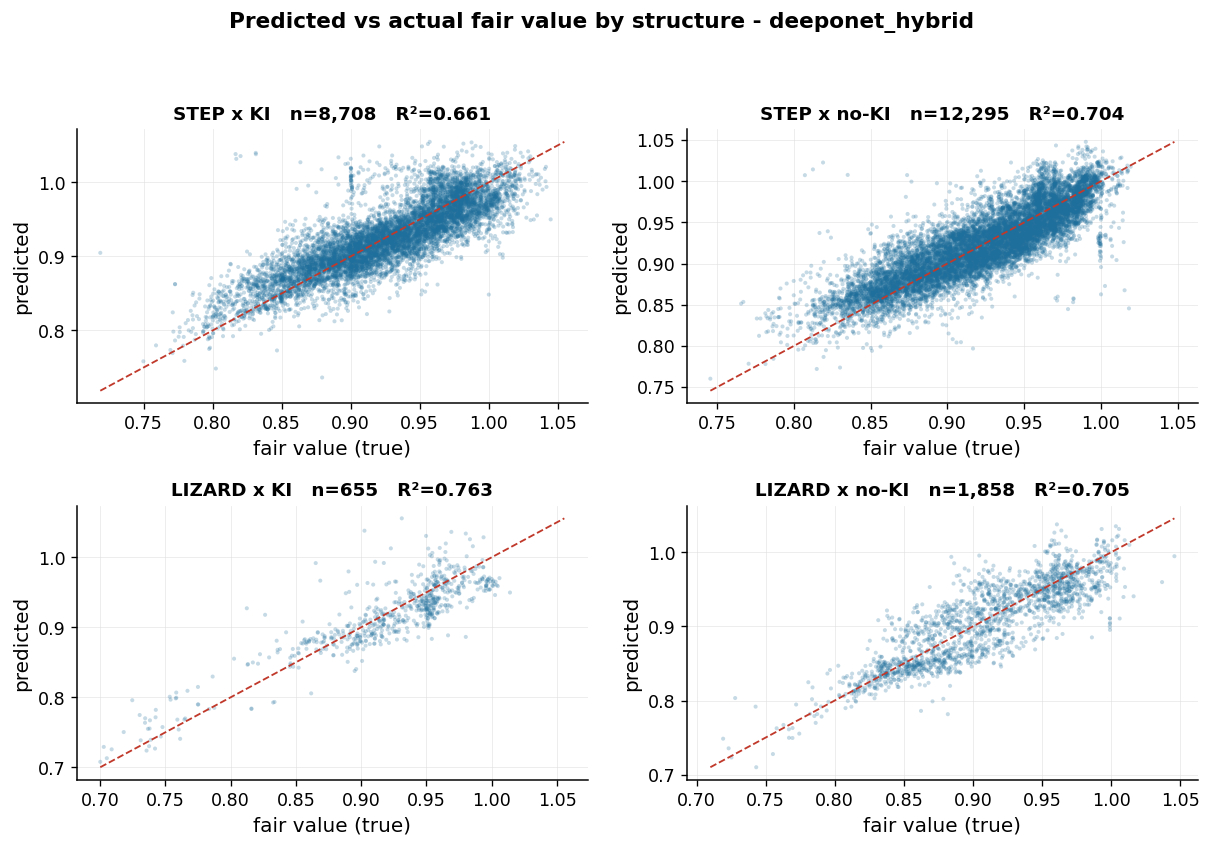

saved -> seg_structure_scatter.png


In [3]:
# 그림 2: 구조별 예측 vs 실제 산점 (대표 모델)
d = M[M.model == BEST]
fig, axs = plt.subplots(2, 2, figsize=(_plot.SLIDE_W * 0.78, 7.2))
for a, s in zip(axs.ravel(), STRUCTS):
    g = d[d.struct == s]
    lim = [min(g.y_true.min(), g.y_pred.min()), max(g.y_true.max(), g.y_pred.max())]
    a.scatter(g.y_true, g.y_pred, s=6, alpha=0.25, color="#1f6f9c", edgecolors="none")
    a.plot(lim, lim, "--", color="#c0392b", lw=1.1)
    a.set_title(f"{s}   n={len(g):,}   R²={r2_score(g.y_true, g.y_pred):.3f}", fontsize=11)
    a.set_xlabel("fair value (true)"); a.set_ylabel("predicted")
    a.grid(color="#dddddd", lw=0.5, alpha=0.6)
for a in axs.ravel()[len(STRUCTS):]:
    a.axis("off")
fig.suptitle(f"Predicted vs actual fair value by structure - {BEST}", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(fm.image("seg_structure_scatter"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_structure_scatter").name)

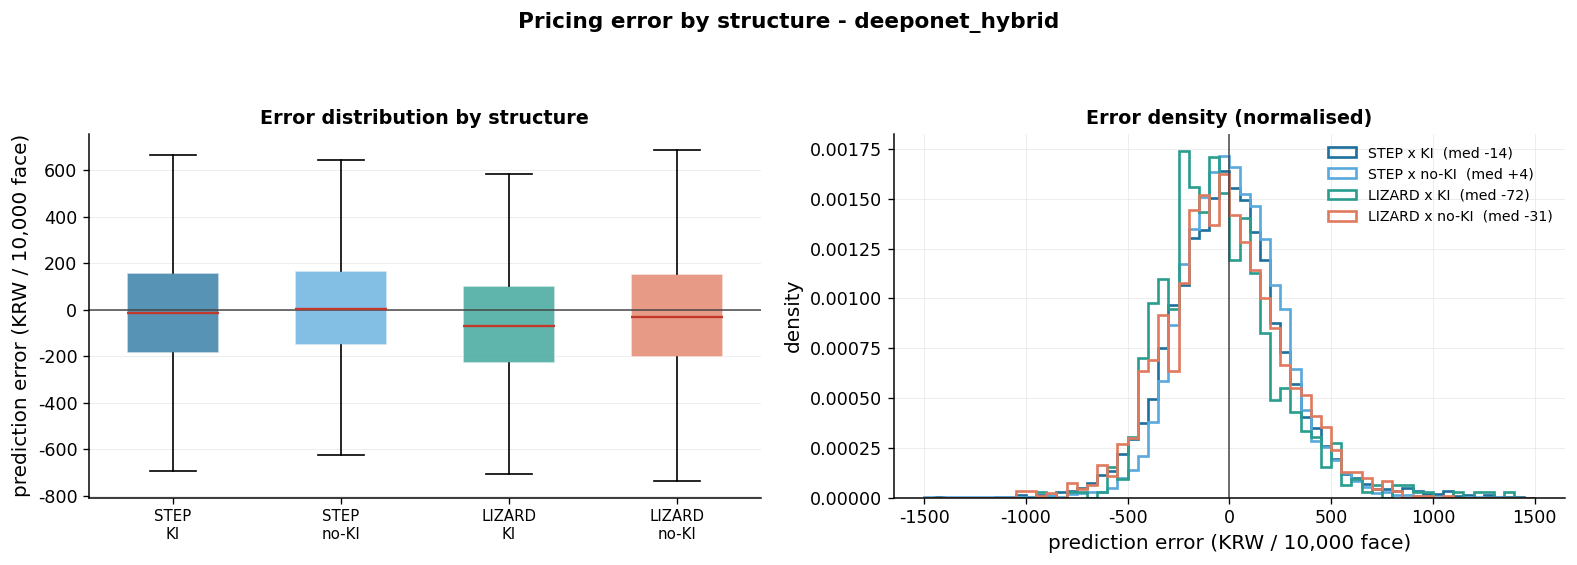

saved -> seg_structure_error.png


In [4]:
# 그림 3: 구조별 오차 분포 (원 단위) — 박스 + 개별 점 일부
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8))
dat = [d[d.struct == s].err.values * FACE for s in STRUCTS]
bp = ax[0].boxplot(dat, vert=True, patch_artist=True, showfliers=False,
                   medianprops=dict(color="#c0392b", lw=1.4), widths=0.55)
for patch, c in zip(bp["boxes"], _plot._QUAL):
    patch.set_facecolor(c); patch.set_alpha(0.75); patch.set_edgecolor("white")
ax[0].axhline(0, color="#444", lw=0.9)
ax[0].set_xticklabels([s.replace(" x ", "\n") for s in STRUCTS], fontsize=9)
ax[0].set_ylabel("prediction error (KRW / 10,000 face)")
ax[0].set_title("Error distribution by structure", fontsize=11.5)
ax[0].grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)

for j, s in enumerate(STRUCTS):
    e = d[d.struct == s].err.values * FACE
    ax[1].hist(e, bins=60, range=(-1500, 1500), histtype="step", linewidth=1.6,
               color=_plot._QUAL[j], label=f"{s}  (med {np.median(e):+.0f})", density=True)
ax[1].axvline(0, color="#444", lw=0.9)
ax[1].set_xlabel("prediction error (KRW / 10,000 face)"); ax[1].set_ylabel("density")
ax[1].set_title("Error density (normalised)", fontsize=11.5)
ax[1].legend(fontsize=8.5); ax[1].grid(color="#dddddd", lw=0.5, alpha=0.6)

fig.suptitle(f"Pricing error by structure - {BEST}", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("seg_structure_error"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_structure_error").name)

## 5-2. 기초자산별 성능

바스켓 **조합**(3개 묶음)과 **개별 지수 포함 여부**를 나눠서 본다. 후자는 한 상품이 3개 지수에
각각 계상되므로 합계가 표본 수를 넘는다 — "그 지수가 들어간 상품의 성능"으로 읽어야 한다.

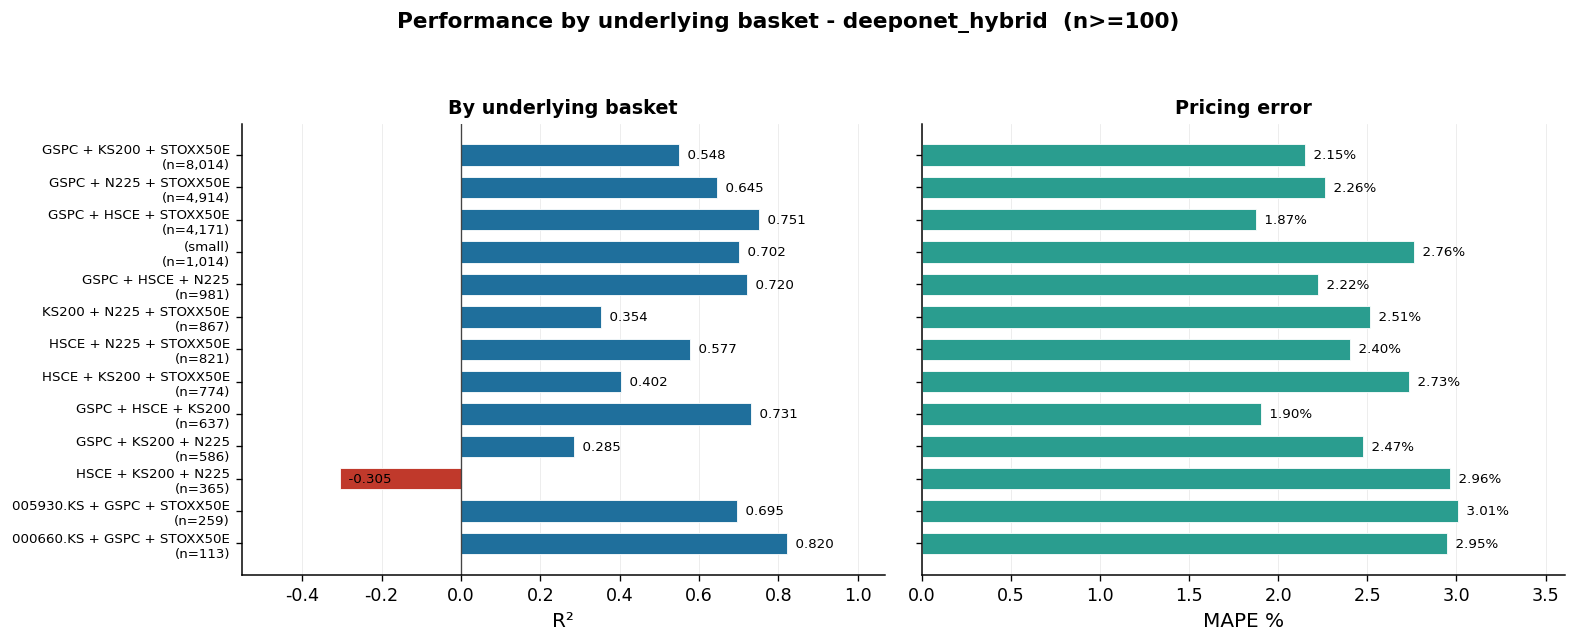

                              n      R2   MAPE%   Bias%
^GSPC|^KS200|^STOXX50E     8014  0.5482  2.1482  0.2453
^GSPC|^N225|^STOXX50E      4914  0.6448  2.2619  0.4151
^GSPC|^HSCE|^STOXX50E      4171  0.7514  1.8746  0.2159
(small)                    1014  0.7016  2.7591 -0.5103
^GSPC|^HSCE|^N225           981  0.7197  2.2238  0.0603
^KS200|^N225|^STOXX50E      867  0.3541  2.5118 -0.7063
^HSCE|^N225|^STOXX50E       821  0.5772  2.4048 -1.2399
^HSCE|^KS200|^STOXX50E      774  0.4025  2.7310 -0.5482
^GSPC|^HSCE|^KS200          637  0.7315  1.9040 -0.8688
^GSPC|^KS200|^N225          586  0.2848  2.4749 -0.7987
^HSCE|^KS200|^N225          365 -0.3048  2.9618 -0.6346
005930.KS|^GSPC|^STOXX50E   259  0.6954  3.0084  1.6945
000660.KS|^GSPC|^STOXX50E   113  0.8203  2.9488  1.6496
saved -> seg_underlying_basket.png


In [5]:
# 그림 4: 바스켓 조합별 R² · MAPE (표본 100건 이상)
BU = {name: metrics_by(M[M.model == name].y_true, M[M.model == name].y_pred,
                       M[M.model == name].udl_key, min_n=100) for name in MODELS}
pd.concat(BU, names=["model", "group"]).to_csv(fm.stat("seg_underlying_basket"))
U = BU[BEST].sort_values("n", ascending=False)
lab = [f"{i.replace('^','').replace('|',' + ')[:34]}\n(n={int(v):,})" for i, v in zip(U.index, U["n"])]

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, max(4.6, 0.42 * len(U))))
y = np.arange(len(U))
cols = ["#c0392b" if r < 0 else "#1f6f9c" for r in U["R2"]]
ax[0].barh(y, U["R2"].values, height=0.66, color=cols, edgecolor="white", linewidth=0.5)
ax[0].set_yticks(y); ax[0].set_yticklabels(lab, fontsize=8); ax[0].invert_yaxis()
ax[0].axvline(0, color="#444", lw=0.8)
for i, v in enumerate(U["R2"].values):
    ax[0].text(v, i, f"  {v:.3f}", va="center", fontsize=8)
ax[0].set_xlabel("R²"); ax[0].set_title("By underlying basket", fontsize=11.5)
ax[0].grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); ax[0].margins(x=0.22)

ax[1].barh(y, U["MAPE%"].values, height=0.66, color="#2a9d8f", edgecolor="white", linewidth=0.5)
ax[1].set_yticks(y); ax[1].set_yticklabels([]); ax[1].invert_yaxis()
for i, v in enumerate(U["MAPE%"].values):
    ax[1].text(v, i, f"  {v:.2f}%", va="center", fontsize=8)
ax[1].set_xlabel("MAPE %"); ax[1].set_title("Pricing error", fontsize=11.5)
ax[1].grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); ax[1].margins(x=0.20)

fig.suptitle(f"Performance by underlying basket - {BEST}  (n>=100)", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(fm.image("seg_underlying_basket"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print(U[["n", "R2", "MAPE%", "Bias%"]].round(4).to_string())
print("saved ->", fm.image("seg_underlying_basket").name)

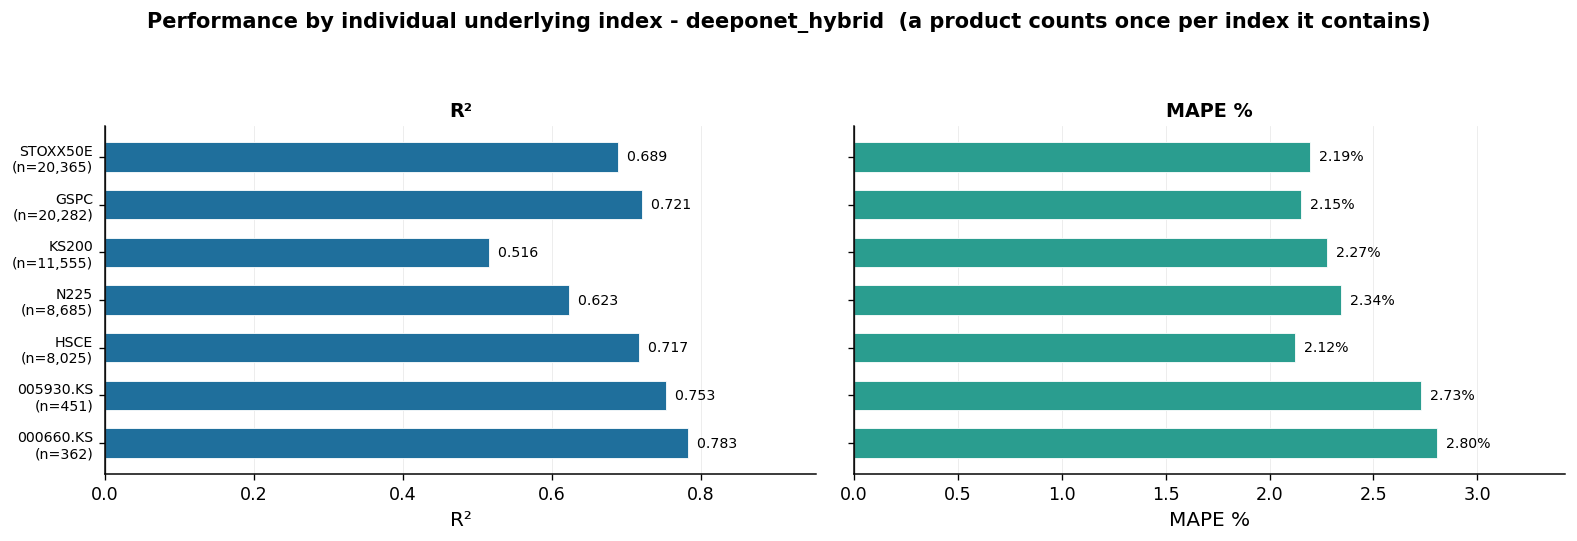

   ticker     n     R2   MAPE    BiasKRW
 STOXX50E 20365 0.6888 2.1950   8.470500
     GSPC 20282 0.7206 2.1516  15.174900
    KS200 11555 0.5162 2.2746  -9.353500
     N225  8685 0.6229 2.3443  -9.801800
     HSCE  8025 0.7168 2.1205 -21.594299
005930.KS   451 0.7529 2.7281  55.501701
000660.KS   362 0.7830 2.8046  35.205601
saved -> seg_underlying_ticker.png


In [6]:
# 그림 5: 개별 지수 포함 여부별 R² · MAPE (한 상품이 3개 지수에 계상됨)
def by_ticker(d0, min_n=200):
    tk = pd.unique(pd.concat([d0.udl1, d0.udl2, d0.udl3]).dropna())
    out = []
    for t in tk:
        g = d0[(d0.udl1 == t) | (d0.udl2 == t) | (d0.udl3 == t)]
        if len(g) < min_n:
            continue
        out.append(dict(ticker=t.replace("^", ""), n=len(g), R2=r2_score(g.y_true, g.y_pred),
                        MAPE=g.ape.mean(), BiasKRW=g.err.mean() * FACE))
    return pd.DataFrame(out).sort_values("n", ascending=False).reset_index(drop=True)

T = by_ticker(M[M.model == BEST])
pd.concat({name: by_ticker(M[M.model == name]) for name in MODELS},
          names=["model", "i"]).to_csv(fm.stat("seg_underlying_ticker"))

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, max(4.6, 0.5 * len(T))))
y = np.arange(len(T))
YL = [f"{t}\n(n={int(nn):,})" for t, nn in zip(T.ticker, T.n)]
for a, col, lab, cmapc in ((ax[0], "R2", "R²", None), (ax[1], "MAPE", "MAPE %", "#2a9d8f")):
    v = T[col].values
    c = ["#c0392b" if x < 0 else "#1f6f9c" for x in v] if cmapc is None else cmapc
    a.barh(y, v, height=0.62, color=c, edgecolor="white", linewidth=0.5)
    a.set_yticks(y); a.set_yticklabels(YL if a is ax[0] else [], fontsize=8.5)
    a.invert_yaxis(); a.axvline(0, color="#444", lw=0.8)
    fmt = "  {:.3f}" if col == "R2" else "  {:.2f}%"
    for i, x in enumerate(v):
        a.text(x, i, fmt.format(x), va="center", fontsize=8.5)
    a.set_xlabel(lab); a.set_title(lab, fontsize=11.5)
    a.grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); a.margins(x=0.22)
fig.suptitle(f"Performance by individual underlying index - {BEST}"
             "  (a product counts once per index it contains)", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(fm.image("seg_underlying_ticker"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print(T.round(4).to_string(index=False))
print("saved ->", fm.image("seg_underlying_ticker").name)

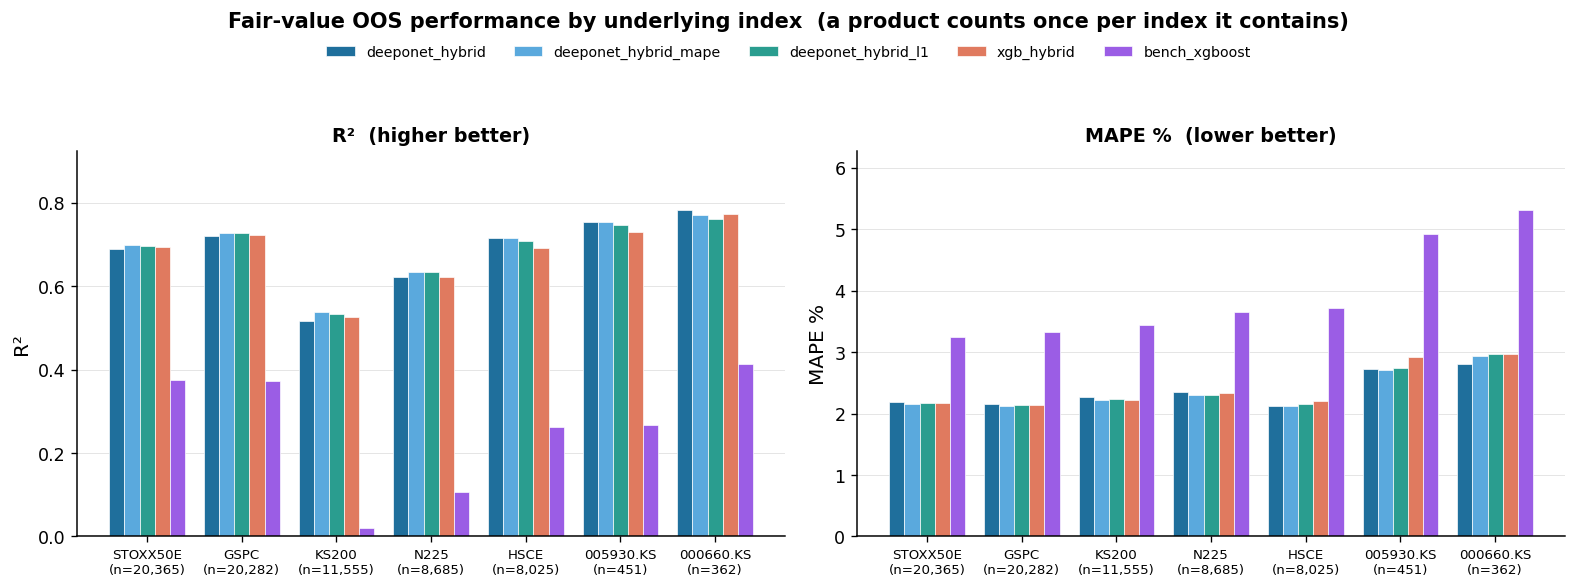

model      bench_xgboost  deeponet_hybrid  deeponet_hybrid_l1  deeponet_hybrid_mape  xgb_hybrid
ticker                                                                                         
STOXX50E          0.3754           0.6888              0.6964                0.6980      0.6942
GSPC              0.3733           0.7206              0.7268                0.7281      0.7217
KS200             0.0198           0.5162              0.5322                0.5379      0.5268
N225              0.1067           0.6229              0.6341                0.6348      0.6230
HSCE              0.2624           0.7168              0.7074                0.7157      0.6909
005930.KS         0.2674           0.7529              0.7479                0.7542      0.7304
000660.KS         0.4127           0.7830              0.7610                0.7697      0.7727
saved -> seg_underlying_metrics.png | seg_underlying_metrics.csv


In [7]:
# 그림 5b: 기초자산 지수별 R² · MAPE — 모델 그룹바 (그림 1 의 구조별 판과 같은 형식)
TK = list(T.ticker)                                     # 그림 5 에서 만든 대표 모델 기준 순서(표본 내림차순)
rows = []
for name in MODELS:
    d0 = M[M.model == name]
    for t in TK:
        g = d0[(d0.udl1 == "^" + t) | (d0.udl2 == "^" + t) | (d0.udl3 == "^" + t)
               | (d0.udl1 == t) | (d0.udl2 == t) | (d0.udl3 == t)]
        if not len(g):
            continue
        rows.append(dict(model=name, ticker=t, n=len(g), R2=r2_score(g.y_true, g.y_pred),
                         MAPE=g.ape.mean(), BiasKRW=g.err.mean() * FACE))
UM = pd.DataFrame(rows)
UM.to_csv(fm.stat("seg_underlying_metrics"), index=False)

XL = [f"{t}\n(n={int(UM[UM.ticker == t].n.iloc[0]):,})" for t in TK]
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 5.0))
x = np.arange(len(TK)); w = 0.8 / len(MODELS)
for j, name in enumerate(MODELS):
    v = UM[UM.model == name].set_index("ticker").reindex(TK)
    off = (j - (len(MODELS) - 1) / 2) * w
    c = _plot._QUAL[j % len(_plot._QUAL)]
    ax[0].bar(x + off, v["R2"].values, w, label=name, color=c, edgecolor="white", linewidth=0.4)
    ax[1].bar(x + off, v["MAPE"].values, w, label=name, color=c, edgecolor="white", linewidth=0.4)
for a, lab, ttl in ((ax[0], "R²", "R²  (higher better)"),
                    (ax[1], "MAPE %", "MAPE %  (lower better)")):
    a.set_xticks(x); a.set_xticklabels(XL, fontsize=8)
    a.axhline(0, color="#444", lw=0.7); a.set_ylabel(lab); a.set_title(ttl, fontsize=11.5)
    a.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5); a.margins(y=0.18)
h, l = ax[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=len(MODELS), bbox_to_anchor=(0.5, 0.945),
           fontsize=8.5, frameon=False)
fig.suptitle("Fair-value OOS performance by underlying index"
             "  (a product counts once per index it contains)", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(fm.image("seg_underlying_metrics"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print(UM.pivot(index="ticker", columns="model", values="R2").reindex(TK).round(4).to_string())
print("saved ->", fm.image("seg_underlying_metrics").name, "|", fm.stat("seg_underlying_metrics").name)

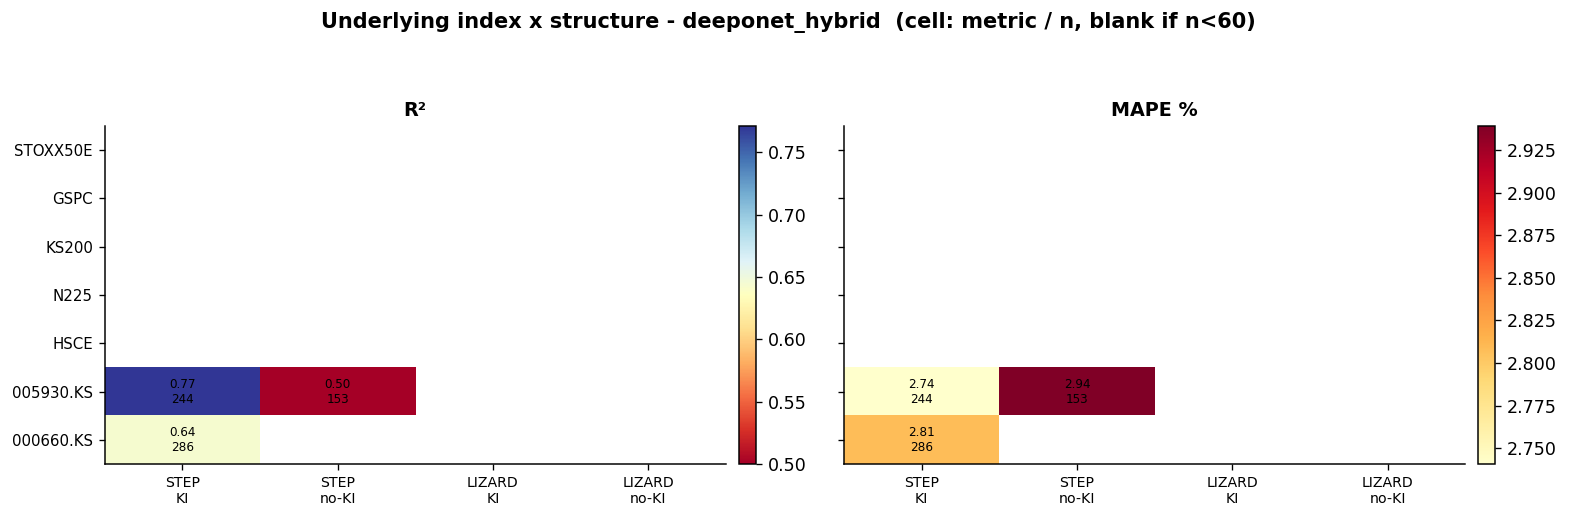

saved -> seg_underlying_x_structure.png


In [8]:
# 그림 6: 지수 × 구조 히트맵 (R² 와 MAPE%)
TK = list(T.ticker)
H_r2 = np.full((len(TK), len(STRUCTS)), np.nan)
H_mp = np.full((len(TK), len(STRUCTS)), np.nan)
H_n = np.zeros((len(TK), len(STRUCTS)), int)
for i, t in enumerate(TK):
    for j, s in enumerate(STRUCTS):
        g = d[(d.struct == s) & ((d.udl1 == t) | (d.udl2 == t) | (d.udl3 == t))]
        H_n[i, j] = len(g)
        if len(g) >= 60:
            H_r2[i, j] = r2_score(g.y_true, g.y_pred); H_mp[i, j] = g.ape.mean()

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, max(4.4, 0.5 * len(TK))))
for a, H, lab, cmap in [(ax[0], H_r2, "R²", "RdYlBu"), (ax[1], H_mp, "MAPE %", "YlOrRd")]:
    im = a.imshow(H, aspect="auto", cmap=cmap)
    a.set_xticks(range(len(STRUCTS)))
    a.set_xticklabels([s.replace(" x ", "\n") for s in STRUCTS], fontsize=8.5)
    a.set_yticks(range(len(TK)))
    a.set_yticklabels([t.replace("^", "") for t in TK] if a is ax[0] else [], fontsize=9)
    for i in range(len(TK)):
        for j in range(len(STRUCTS)):
            if not np.isnan(H[i, j]):
                a.text(j, i, f"{H[i,j]:.2f}\n{H_n[i,j]:,}", ha="center", va="center", fontsize=7.2)
    a.set_title(lab, fontsize=11.5)
    fig.colorbar(im, ax=a, fraction=0.046, pad=0.02)
fig.suptitle(f"Underlying index x structure - {BEST}  (cell: metric / n, blank if n<60)",
             fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(fm.image("seg_underlying_x_structure"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_underlying_x_structure").name)

## 5-3. 시기별 안정성 (walk-forward 폴드 × 구조)

폴드 0 은 train 이 가장 적고(60%) 그 test 구간이 HSCEI 급락 직전이라, 학습에 없던 국면으로
외삽하게 된다. 구조별로도 같은 패턴인지 확인한다.

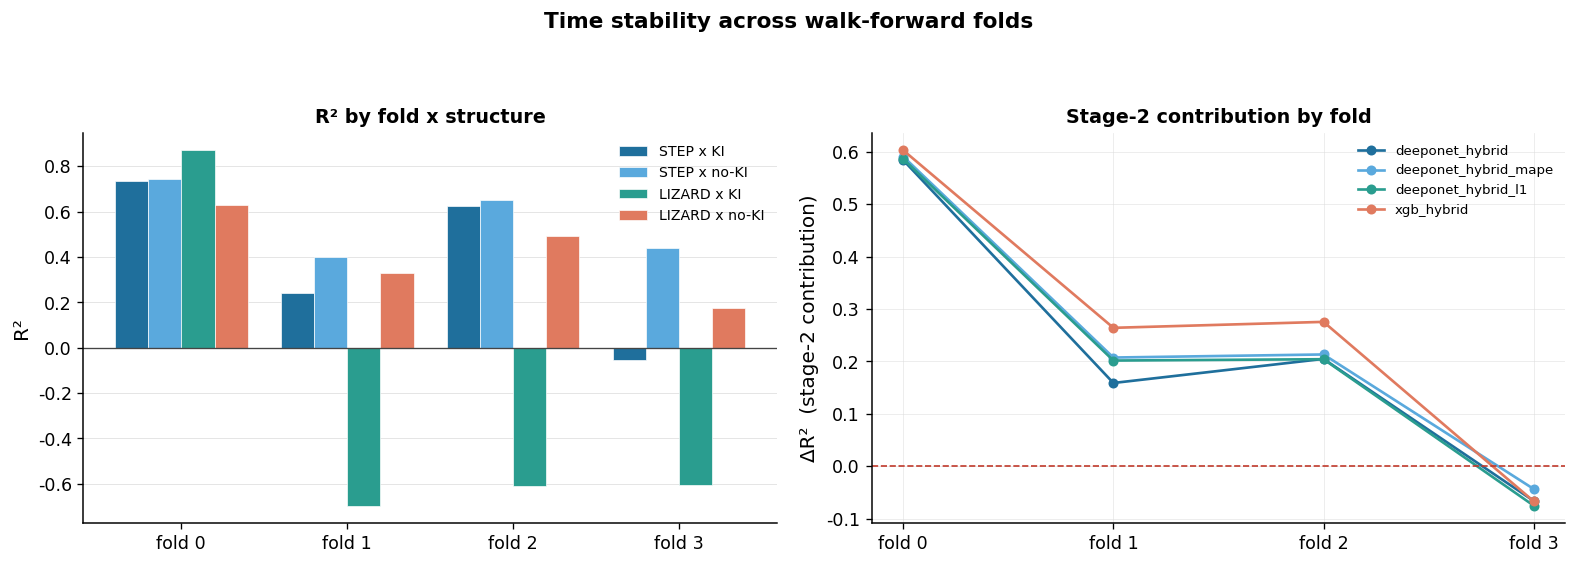

saved -> seg_fold_stability.png


In [9]:
# 그림 7: 폴드 × 구조 R² + stage2 기여
nf = len(D.WF)
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8))
x = np.arange(nf); w = 0.8 / max(len(STRUCTS), 1)
for j, s in enumerate(STRUCTS):
    v, lb = [], []
    for k in range(nf):
        g = d[(d.struct == s) & (d.fold == k)]
        v.append(r2_score(g.y_true, g.y_pred) if len(g) > 30 else np.nan)
        lb.append(len(g))
    ax[0].bar(x + (j - (len(STRUCTS) - 1) / 2) * w, v, w, label=s,
              color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
ax[0].set_xticks(x); ax[0].set_xticklabels([f"fold {k}" for k in range(nf)])
ax[0].axhline(0, color="#444", lw=0.8); ax[0].set_ylabel("R²")
ax[0].set_title("R² by fold x structure", fontsize=11.5)
ax[0].legend(fontsize=8.5); ax[0].grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5)

# stage2 기여 = R2(최종) - R2(MC_hat + margin)
for j, name in enumerate(MODELS):
    dd = M[M.model == name]
    if "resid_pred" not in dd.columns or dd["resid_pred"].isna().all():
        continue
    con = []
    for k in range(nf):
        g = dd[dd.fold == k]
        base = g.y_pred - g.resid_pred
        con.append(r2_score(g.y_true, g.y_pred) - r2_score(g.y_true, base))
    ax[1].plot(x, con, "o-", lw=1.6, ms=5, color=_plot._QUAL[j % len(_plot._QUAL)], label=name)
ax[1].axhline(0, color="#c0392b", lw=1.0, ls="--")
ax[1].set_xticks(x); ax[1].set_xticklabels([f"fold {k}" for k in range(nf)])
ax[1].set_ylabel("ΔR²  (stage-2 contribution)")
ax[1].set_title("Stage-2 contribution by fold", fontsize=11.5)
ax[1].legend(fontsize=8); ax[1].grid(color="#dddddd", lw=0.5, alpha=0.6)

fig.suptitle("Time stability across walk-forward folds", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("seg_fold_stability"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_fold_stability").name)

## 5-4. 단계별(stage) 성능 분해 — 상품 구조별 · 기초자산별

하이브리드는 두 단계다.

```
Fair_hat = MC_hat(stage-1: DeepONet 이 MC 이론가 근사) + recent_margin + Residual_hat(stage-2: 마진 잔차)
```

- **stage-1**: `R²(MC, MC_hat)` — 연산자망이 이론가를 얼마나 재현하나 (이론 파트)
- **stage-2**: `R²(resid, resid_hat)`, `resid = Fair − MC_hat − recent_margin` — 시장 마진을 얼마나 설명하나
- **final**: `R²(Fair, Fair_hat)`

**MAPE 정의**: stage-2 의 타깃(잔차)은 0 을 넘나들어 표준 MAPE(자기 타깃 분모)가 발산한다.
그래서 세 단계 모두 **분모를 그 상품의 공정가로 통일**한 `오차 % = mean(|error| / Fair) × 100` 를 쓴다.
이러면 세 단계가 같은 축에서 비교되고, stage-1·final 은 표준 MAPE 와 거의 같다(분모가 MC vs Fair 로 ~6% 차이).
표준 MAPE 도 CSV 에 `MAPEown%` 로 함께 저장한다(stage-2 는 NaN).

> **R² 읽을 때 주의**: `R² = 1 − MSE/Var(target)` 이라 **타깃 분산이 다른 세그먼트끼리 R² 를 직접 비교하면 오해**한다.
> LIZARD×KI 와 STEP×KI 는 RMSE 가 288 vs 290원으로 사실상 같은데 R² 는 0.76 vs 0.66 이다 —
> 차이는 공정가 표준편차(592 vs 498원)뿐이다. 아래 세 번째 패널이 그 관계를 직접 보인다.

**stage-2 오차 = final 오차 (항등식)**: `resid = Fair − MC_hat − rm` 이고 `Fair_hat = MC_hat + rm + resid_hat`
이므로 `Fair_hat − Fair ≡ resid_hat − resid` 다. 두 단계의 **오차는 같은 값**이고, R² 만 분모가 다르다
(stage-2 는 `Var(resid)`, final 은 `Var(Fair)`). 그래서 오차 패널에는 stage-1 과 final 만 그린다 —
stage-2 의 기여는 **R² 패널**에서 "잔차 분산을 얼마나 설명했나"로 읽어야 한다.

In [10]:
# 단계별 지표 (구조별 · 기초자산별) — R², MAPE(공정가 분모), 표준 MAPE, RMSE(원)
from sklearn.metrics import r2_score

HYB = [m for m in MODELS if "mc_pred" in preds[m].columns]      # 2단계 모델만 (직접 벤치마크 제외)
STAGES = [("stage1", "mc_true", "mc_pred", "MC anchor"),
          ("stage2", "resid_true", "resid_pred", "margin residual"),
          ("final", "y_true", "y_pred", "fair value")]


def _stage_metrics(sub):
    """세 단계 지표. MAPE 는 분모를 공정가로 통일(잔차는 0 을 넘나들어 자기분모 MAPE 가 발산)."""
    fair = sub["y_true"].abs().values
    row = {}
    for sname, tc, pc, _ in STAGES:
        e = (sub[pc] - sub[tc]).values
        row[f"{sname}_R2"] = r2_score(sub[tc], sub[pc])
        row[f"{sname}_MAPE"] = float((np.abs(e) / fair).mean() * 100)          # 공통 분모 = 공정가
        row[f"{sname}_MAPEown"] = (np.nan if sname == "stage2"
                                   else float((np.abs(e) / sub[tc].abs()).mean() * 100))
        row[f"{sname}_RMSE"] = float(np.sqrt((e ** 2).mean()) * FACE)
        row[f"{sname}_SD"] = float(sub[tc].std() * FACE)
    return row


def stage_table(d, group_col, min_n=30):
    out = []
    for g, sub in d.groupby(group_col):
        if len(sub) < min_n:
            continue
        out.append({"group": g, "n": len(sub), **_stage_metrics(sub)})
    return pd.DataFrame(out).set_index("group")


def stage_table_ticker(d, min_n=200):
    tk = pd.unique(pd.concat([d.udl1, d.udl2, d.udl3]).dropna())
    out = []
    for t in tk:
        sub = d[(d.udl1 == t) | (d.udl2 == t) | (d.udl3 == t)]
        if len(sub) < min_n:
            continue
        out.append({"group": t.replace("^", ""), "n": len(sub), **_stage_metrics(sub)})
    return pd.DataFrame(out).sort_values("n", ascending=False).set_index("group")


ST = {m: stage_table(M[M.model == m], "struct") for m in HYB}
UT = {m: stage_table_ticker(M[M.model == m]) for m in HYB}
pd.concat(ST, names=["model", "group"]).to_csv(fm.stat("seg_stage_structure"))
pd.concat(UT, names=["model", "group"]).to_csv(fm.stat("seg_stage_underlying"))

SHOW = ["n", "stage1_R2", "stage2_R2", "final_R2", "stage1_MAPE", "stage2_MAPE", "final_MAPE"]
print(f"=== 상품 구조별 단계 지표 — {BEST}  (MAPE 분모 = 공정가) ===")
print(ST[BEST].reindex(STRUCTS)[SHOW].round(4).to_string())
print(f"\n=== 기초자산 지수별 단계 지표 — {BEST} ===")
print(UT[BEST][SHOW].round(4).to_string())
print("\nsaved ->", fm.stat("seg_stage_structure").name, "|", fm.stat("seg_stage_underlying").name)

=== 상품 구조별 단계 지표 — deeponet_hybrid  (MAPE 분모 = 공정가) ===
                    n  stage1_R2  stage2_R2  final_R2  stage1_MAPE  stage2_MAPE  final_MAPE
group                                                                                      
STEP x KI        8708     0.9619     0.3028    0.6610       0.3950       2.3549      2.3549
STEP x no-KI    12295     0.9708     0.4772    0.7041       0.2709       2.0764      2.0764
LIZARD x KI       655     0.9415     0.0284    0.7632       0.6802       2.4210      2.4210
LIZARD x no-KI   1858     0.8037     0.2955    0.7047       0.6279       2.4920      2.4920

=== 기초자산 지수별 단계 지표 — deeponet_hybrid ===
               n  stage1_R2  stage2_R2  final_R2  stage1_MAPE  stage2_MAPE  final_MAPE
group                                                                                 
STOXX50E   20365     0.9583     0.4065    0.6888       0.3264       2.1950      2.1950
GSPC       20282     0.9517     0.4291    0.7206       0.3437       2.1516      2.1516
KS

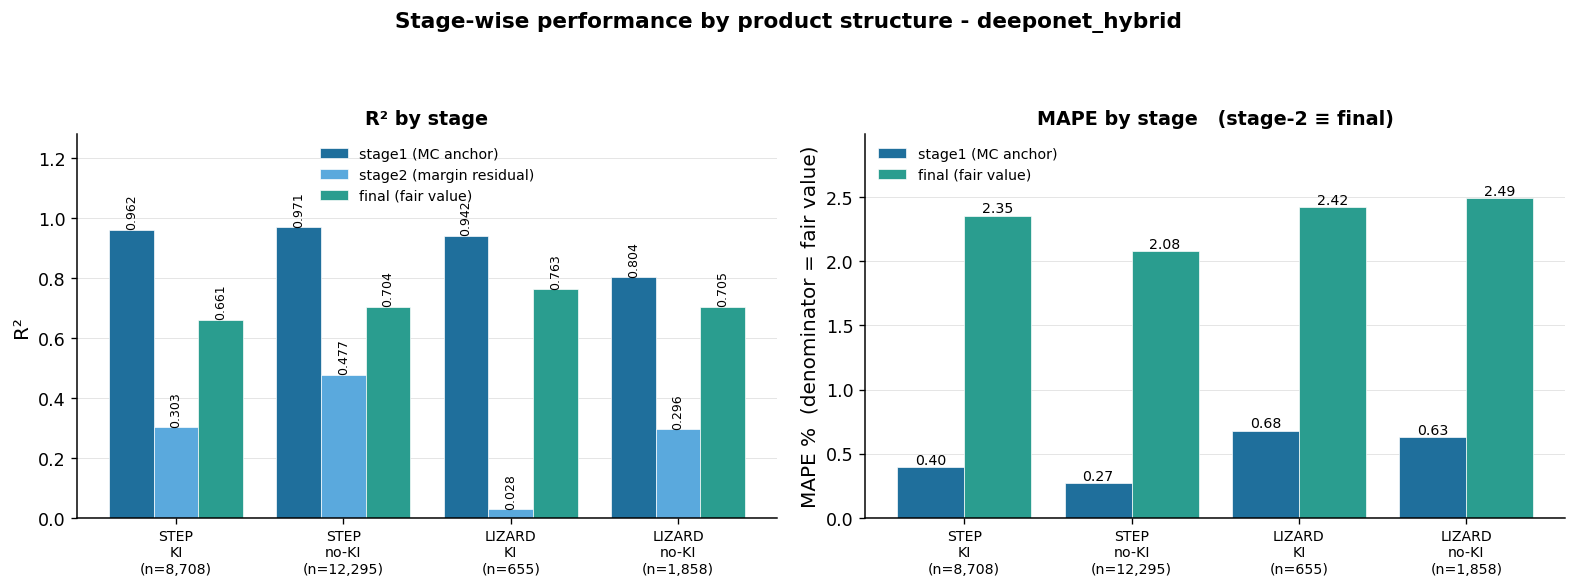

saved -> seg_stage_structure.png


In [11]:
# 그림 8: 상품 구조별 단계 지표 — R² · MAPE
S3 = ST[BEST].reindex(STRUCTS)
ERRS = [s_ for s_ in STAGES if s_[0] != "stage2"]        # MAPE 는 stage2 ≡ final (항등식)
XL = [s.replace(" x ", "\n") + f"\n(n={int(v):,})" for s, v in zip(STRUCTS, S3["n"])]
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 5.0))
x = np.arange(len(STRUCTS))

w1 = 0.8 / len(STAGES)
for j, (sname, _t, _p, lab) in enumerate(STAGES):
    v = S3[f"{sname}_R2"].values
    b = ax[0].bar(x + (j - (len(STAGES) - 1) / 2) * w1, v, w1, label=f"{sname} ({lab})",
                  color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
    for r, val in zip(b, v):
        ax[0].text(r.get_x() + r.get_width() / 2, val, f"{val:.3f}", ha="center",
                   va="bottom" if val >= 0 else "top", fontsize=7.5, rotation=90)
ax[0].set_ylabel("R²"); ax[0].set_title("R² by stage", fontsize=11.5)
ax[0].set_ylim(0, 1.28); ax[0].legend(fontsize=8.5, loc="upper center", framealpha=0.9)

w2 = 0.8 / len(ERRS)
for j, (sname, _t, _p, lab) in enumerate(ERRS):
    v = S3[f"{sname}_MAPE"].values
    c = _plot._QUAL[0] if sname == "stage1" else _plot._QUAL[2]
    b = ax[1].bar(x + (j - (len(ERRS) - 1) / 2) * w2, v, w2, label=f"{sname} ({lab})",
                  color=c, edgecolor="white", linewidth=0.4)
    for r, val in zip(b, v):
        ax[1].text(r.get_x() + r.get_width() / 2, val, f"{val:.2f}", ha="center",
                   va="bottom", fontsize=8.5)
ax[1].set_ylabel("MAPE %  (denominator = fair value)")
ax[1].set_title("MAPE by stage   (stage-2 ≡ final)", fontsize=11.5)
ax[1].legend(fontsize=8.5, loc="upper left"); ax[1].margins(y=0.20)

for a in ax:
    a.set_xticks(x); a.set_xticklabels(XL, fontsize=8.5)
    a.axhline(0, color="#444", lw=0.7)
    a.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5)
fig.suptitle(f"Stage-wise performance by product structure - {BEST}", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("seg_stage_structure"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_stage_structure").name)

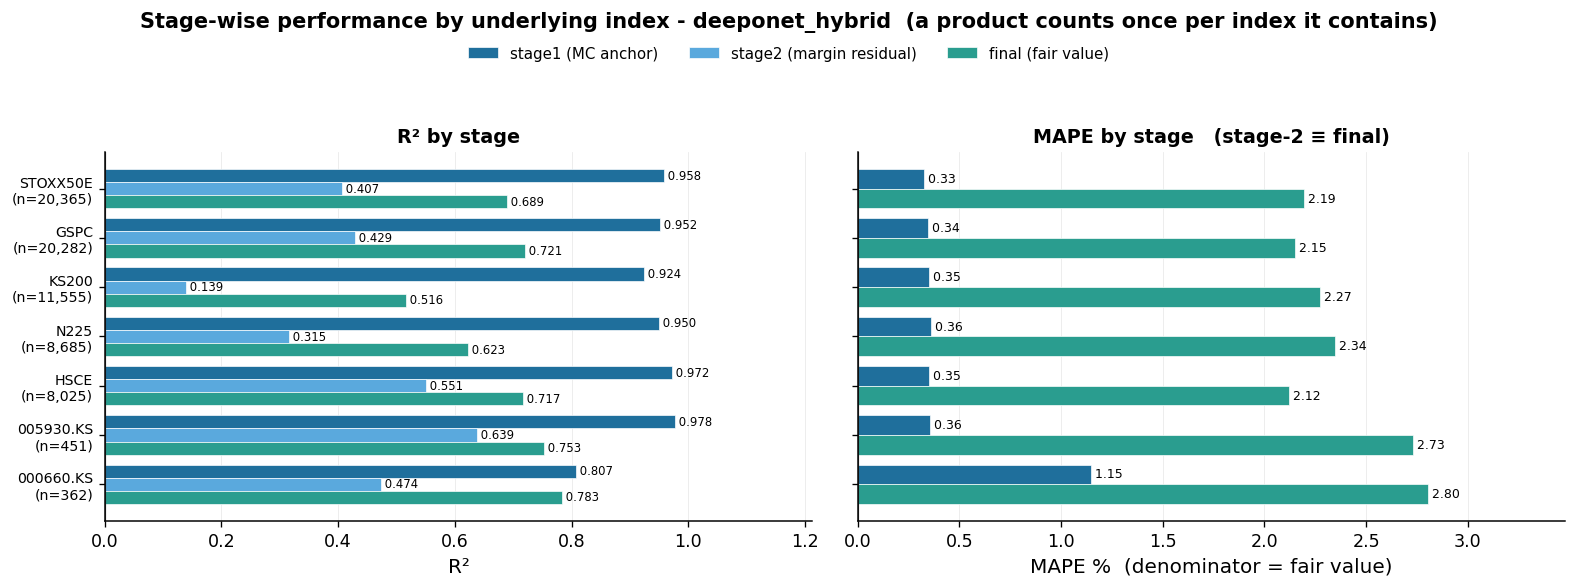

saved -> seg_stage_underlying.png


In [12]:
# 그림 9: 기초자산 지수별 단계 지표 — R² · MAPE
U3 = UT[BEST]
YL = [f"{i}\n(n={int(v):,})" for i, v in zip(U3.index, U3["n"])]
ERRS = [s_ for s_ in STAGES if s_[0] != "stage2"]
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, max(5.0, 0.56 * len(U3))))
y = np.arange(len(U3))

w1 = 0.8 / len(STAGES)
for j, (sname, _t, _p, lab) in enumerate(STAGES):
    v = U3[f"{sname}_R2"].values
    ax[0].barh(y + (j - (len(STAGES) - 1) / 2) * w1, v, w1, label=f"{sname} ({lab})",
               color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
    for k, val in enumerate(v):
        ax[0].text(val, y[k] + (j - (len(STAGES) - 1) / 2) * w1, f" {val:.3f}",
                   va="center", fontsize=7)
ax[0].set_xlabel("R²"); ax[0].set_title("R² by stage", fontsize=11.5)
ax[0].margins(x=0.24)

w2 = 0.8 / len(ERRS)
for j, (sname, _t, _p, lab) in enumerate(ERRS):
    v = U3[f"{sname}_MAPE"].values
    c = _plot._QUAL[0] if sname == "stage1" else _plot._QUAL[2]
    ax[1].barh(y + (j - (len(ERRS) - 1) / 2) * w2, v, w2, label=f"{sname} ({lab})",
               color=c, edgecolor="white", linewidth=0.4)
    for k, val in enumerate(v):
        ax[1].text(val, y[k] + (j - (len(ERRS) - 1) / 2) * w2, f" {val:.2f}",
                   va="center", fontsize=7.5)
ax[1].set_xlabel("MAPE %  (denominator = fair value)")
ax[1].set_title("MAPE by stage   (stage-2 ≡ final)", fontsize=11.5)
ax[1].margins(x=0.24)

for a in ax:
    a.set_yticks(y); a.set_yticklabels(YL if a is ax[0] else [], fontsize=8.5)
    a.invert_yaxis(); a.axvline(0, color="#444", lw=0.7)
    a.grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6)
h, l = ax[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.945),
           fontsize=9, frameon=False)
fig.suptitle(f"Stage-wise performance by underlying index - {BEST}"
             "  (a product counts once per index it contains)", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(fm.image("seg_stage_underlying"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_stage_underlying").name)

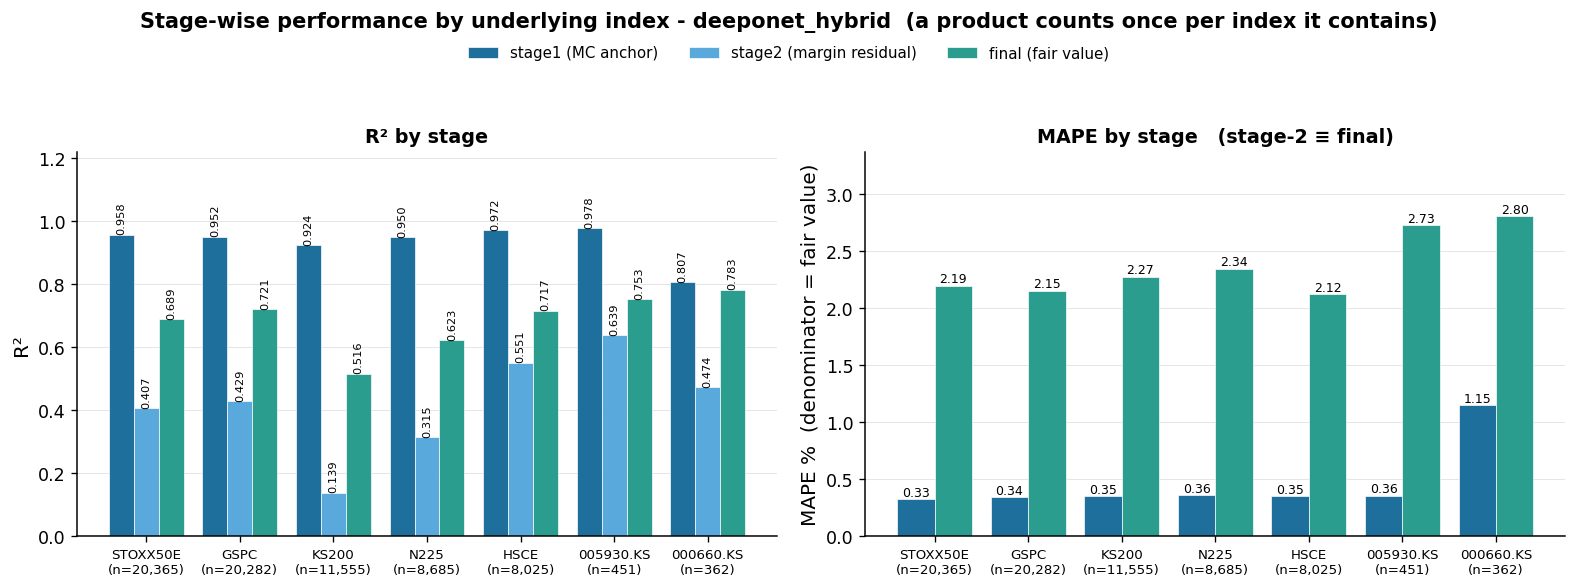

saved -> seg_stage_underlying_vertical.png


In [13]:
# 그림 9b: 기초자산 지수별 단계 지표 — 세로 막대 버전 (그림 9 의 가로판과 같은 수치)
U3 = UT[BEST]
ERRS = [s_ for s_ in STAGES if s_[0] != "stage2"]
XL = [f"{i}\n(n={int(v):,})" for i, v in zip(U3.index, U3["n"])]
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 5.0))
x = np.arange(len(U3))

w1 = 0.8 / len(STAGES)
for j, (sname, _t, _p, lab) in enumerate(STAGES):
    v = U3[f"{sname}_R2"].values
    b = ax[0].bar(x + (j - (len(STAGES) - 1) / 2) * w1, v, w1, label=f"{sname} ({lab})",
                  color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
    for r, val in zip(b, v):
        ax[0].text(r.get_x() + r.get_width() / 2, val, f"{val:.3f}", ha="center",
                   va="bottom" if val >= 0 else "top", fontsize=6.8, rotation=90)
ax[0].set_ylabel("R²"); ax[0].set_title("R² by stage", fontsize=11.5)
ax[0].set_ylim(0, 1.22)

w2 = 0.8 / len(ERRS)
for j, (sname, _t, _p, lab) in enumerate(ERRS):
    v = U3[f"{sname}_MAPE"].values
    c = _plot._QUAL[0] if sname == "stage1" else _plot._QUAL[2]
    b = ax[1].bar(x + (j - (len(ERRS) - 1) / 2) * w2, v, w2, label=f"{sname} ({lab})",
                  color=c, edgecolor="white", linewidth=0.4)
    for r, val in zip(b, v):
        ax[1].text(r.get_x() + r.get_width() / 2, val, f"{val:.2f}", ha="center",
                   va="bottom", fontsize=7.5)
ax[1].set_ylabel("MAPE %  (denominator = fair value)")
ax[1].set_title("MAPE by stage   (stage-2 ≡ final)", fontsize=11.5)
ax[1].margins(y=0.20)

for a in ax:
    a.set_xticks(x); a.set_xticklabels(XL, fontsize=8)
    a.axhline(0, color="#444", lw=0.7)
    a.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5)

h, l = ax[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.945),
           fontsize=9, frameon=False)
fig.suptitle(f"Stage-wise performance by underlying index - {BEST}"
             "  (a product counts once per index it contains)", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(fm.image("seg_stage_underlying_vertical"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_stage_underlying_vertical").name)

## 5-5. 요약

In [14]:
# 요약 표 (구조 × 모델 R²) + 저장물 목록
piv = S.pivot(index="struct", columns="model", values="R2").reindex(STRUCTS).round(4)
print("=== 구조별 R² ===")
print(piv.to_string())
print("\n=== 기초자산 지수별 R² (대표 모델) ===")
print(T[["ticker", "n", "R2", "MAPE", "BiasKRW"]].round(4).to_string(index=False))
print("\nsaved images ->", [p.name for p in sorted(fm.IMAGE.glob("seg_*.png"))])
print("saved stats  ->", [p.name for p in sorted(fm.STAT.glob("seg_*.csv"))])

=== 구조별 R² ===
model           bench_xgboost  deeponet_hybrid  deeponet_hybrid_l1  deeponet_hybrid_mape  xgb_hybrid
struct                                                                                              
STEP x KI              0.1772           0.6610              0.6600                0.6646      0.6522
STEP x no-KI           0.4613           0.7041              0.7169                0.7184      0.7135
LIZARD x KI            0.2693           0.7632              0.7667                0.7572      0.7850
LIZARD x no-KI         0.2395           0.7047              0.7006                0.7086      0.6779

=== 기초자산 지수별 R² (대표 모델) ===
   ticker     n     R2   MAPE    BiasKRW
 STOXX50E 20365 0.6888 2.1950   8.470500
     GSPC 20282 0.7206 2.1516  15.174900
    KS200 11555 0.5162 2.2746  -9.353500
     N225  8685 0.6229 2.3443  -9.801800
     HSCE  8025 0.7168 2.1205 -21.594299
005930.KS   451 0.7529 2.7281  55.501701
000660.KS   362 0.7830 2.8046  35.205601

saved images -> ['seg